# Ho Chi Minh City - PM2.5 Air Quality Forecasting

## Project Overview
This is a **univariate time series forecasting problem**. The target variable is `PM2.5` (fine particulate matter, µg/m³) measured hourly at Station 1 in HCMC (Ho Chi Minh City). Raw sensor data is ingested from CSV into a local **MongoDB** database, then queried, wrangled, and modelled using three progressively sophisticated approaches:
- **Linear Regression with a lag feature** - bridges tabular ML intuition into time series thinking
- **AutoRegression (AR)** - uses multiple past hours simultaneously; lag order selected via PACF analysis
- **ARMA (AutoRegressive Moving Average)** - adds a moving average component; best (p,q) found via grid search

All models are evaluated using **walk-forward validation**, the time series equivalent of cross-validation.

**Target variable:** `PM2.5` (µg/m³)  
**Dataset:** HealthyAir - Outdoor Air Quality in Ho Chi Minh City, Vietnam (Mendeley Data, CC BY 4.0)  
**Source:** https://data.mendeley.com/datasets/pk6tzrjks8/1  
**Citation:** Rakholia et al. (2022). DOI: 10.17632/pk6tzrjks8.1

---
## 1: Setup & Data Ingestion into MongoDB

In [1]:
from pprint import PrettyPrinter
import pandas as pd
from pymongo import MongoClient

pp = PrettyPrinter(indent=2)

In [2]:
# Connect to local MongoDB
client = MongoClient(host='localhost', port=27017)
print('Connected. Databases:', client.list_database_names())

Connected. Databases: ['admin', 'config', 'local']


In [11]:
# Connect to our database and collection
db = client['air-quality']
hcmc = db['hcmc']

# Ingest CSV into MongoDB
if hcmc.count_documents({}) == 0:
    print('Collection empty. Loading CSV into MongoDB...')
    raw = pd.read_csv('data/AirQuality_hcmc.csv')
    print('CSV shape:', raw.shape)
    print('Columns:', raw.columns.tolist())
    hcmc.insert_many(raw.to_dict(orient='records'))
    print(f'Inserted {hcmc.count_documents({}):,} documents.')
else:
    print(f'Already loaded: {hcmc.count_documents({}):,} documents.')

Already loaded: 52,548 documents.


In [4]:
# Inspect one document to understand the structure
pp.pprint(hcmc.find_one({}))

{ 'CO': 1330.451429,
  'Humidity': 63.18809524,
  'NO2': 112.7407619,
  'O3': 55.43138095,
  'PM2.5': 15.6047619,
  'SO2': 393.0,
  'Station_No': 1,
  'TSP': 32.93571429,
  'Temperature': 28.36190476,
  '_id': ObjectId('69c663563bc900a6b9e2b94b'),
  'date': '23-02-2021 21:00'}


In [5]:
# How many stations and readings per station?
print('Unique stations:', hcmc.distinct('Station_No'))
result = hcmc.aggregate([
    {'$group': {'_id': '$Station_No', 'count': {'$count': {}}}},
    {'$sort': {'_id': 1}}
])
pp.pprint(list(result))

Unique stations: [1, 2, 3, 4, 5, 6]
[ {'_id': 1, 'count': 7892},
  {'_id': 2, 'count': 9357},
  {'_id': 3, 'count': 8418},
  {'_id': 4, 'count': 9951},
  {'_id': 5, 'count': 7431},
  {'_id': 6, 'count': 9499}]


In [6]:
# Preview PM2.5 readings from Station 1 (traffic zone)
result = hcmc.find(
    {'Station_No': 1},
    projection={'date': 1, 'PM2.5': 1, 'Temperature': 1, 'Humidity': 1, '_id': 0}
).limit(5)
pp.pprint(list(result))

[ { 'Humidity': 63.18809524,
    'Temperature': 28.36190476,
    'date': '23-02-2021 21:00'},
  { 'Humidity': 63.77352941,
    'Temperature': 28.32058824,
    'date': '23-02-2021 22:00'},
  {'Humidity': 64.205, 'Temperature': 28.33666667, 'date': '23-02-2021 23:00'},
  {'Humidity': 64.735, 'Temperature': 28.305, 'date': '24-02-2021 00:00'},
  {'Humidity': 65.18833333, 'Temperature': 28.3, 'date': '24-02-2021 01:00'}]


---
## 2: Wrangling & Exploratory Data Analysis

In [7]:
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action='ignore', category=FutureWarning)

In [18]:
# wrangle function: Basic query and parse
def wrangle(collection, station=1, resample_rule='1H'):
    # Retrieve all fields (no projection) to avoid dot-notation issues
    results = collection.find({'Station_No': station})
    df = pd.DataFrame(list(results))
    
    # Drop MongoDB internal id column
    df.drop(columns=['_id'], inplace=True, errors='ignore')
    
    # Parse datetime and set as index
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.set_index('date').sort_index()
    
    return df

df = wrangle(hcmc)
print('Shape:', df.shape)
df.head()

Shape: (7892, 9)


,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
date,,,,,,,,,
2021-02-23 21:00:00,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
2021-02-23 22:00:00,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2021-02-23 23:00:00,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
2021-02-24 00:00:00,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
2021-02-24 01:00:00,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333


In [15]:
# check null counts and percentage
print(df.info())
print('\nNull count: ', df['PM2.5'].isnull().sum())
print('Null percentage: {:.1f}%'.format(df['PM2.5'].isnull().mean() * 100))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7892 entries, 2021-02-23 21:00:00 to 2022-06-21 17:00:00
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Station_No   7892 non-null   int64  
 1   TSP          7832 non-null   float64
 2   PM2.5        7892 non-null   float64
 3   O3           2227 non-null   float64
 4   CO           7827 non-null   float64
 5   NO2          2227 non-null   float64
 6   SO2          2183 non-null   float64
 7   Temperature  7892 non-null   float64
 8   Humidity     7892 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 616.6 KB
None

Null count:  0
Null percentage: 0.0%


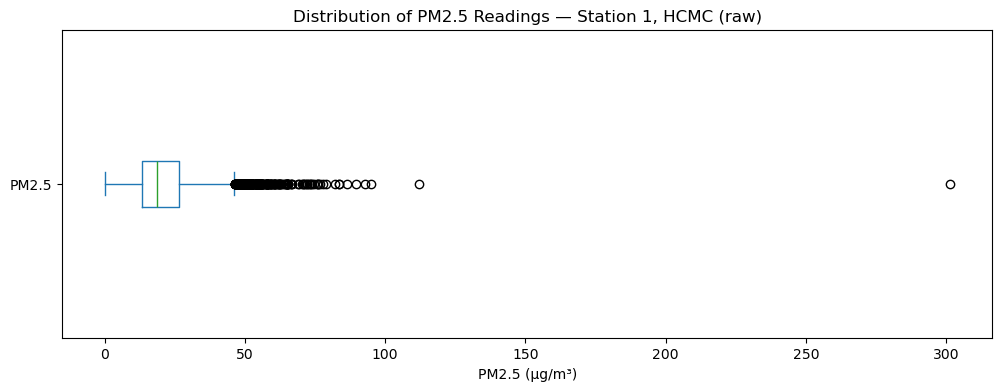

count    7892.000000
mean       20.820765
std        11.860370
min         0.000000
25%        13.166667
50%        18.544167
75%        26.419167
max       301.428333
Name: PM2.5, dtype: float64

In [17]:
# Check outliers with a boxplot
fig, ax = plt.subplots(figsize=(12, 4))
df['PM2.5'].plot(kind='box', vert=False, ax=ax)
plt.xlabel('PM2.5 (µg/m³)')
plt.title('Distribution of PM2.5 Readings — Station 1, HCMC (raw)')
plt.show()
df['PM2.5'].describe()

In [19]:
# Full wrangle function: timezone, outliers, resample, forward-fill
def wrangle(collection, station=1, resample_rule='1H'):
    results = collection.find({'Station_No': station})
    df = pd.DataFrame(list(results))
    
    # Drop MongoDB internal id column
    df.drop(columns=['_id'], inplace=True, errors='ignore')
    
    # Parse datetime and set index
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df = df.set_index('date').sort_index()
    
    # Localize to Vietnam timezone (UTC+7)
    # Ensures daily pollution patterns align with correct local hours
    df.index = df.index.tz_localize('Asia/Ho_Chi_Minh')
    
    # Remove sensor errors: negative values and extreme spikes
    # Negative values are physically impossible for PM2.5
    df = df[df['PM2.5'] >= 0]
    df = df[df['PM2.5'] < 100]  # cap extreme outliers
    
    # Resample to hourly means, forward-fill missing hours
    # Forward-fill reflects real monitoring system behavior:
    # hold last known reading until a new one arrives
    y = df['PM2.5'].resample(resample_rule).mean().fillna(method='ffill')
    
    return y

y = wrangle(hcmc)
print('Type:', type(y))
print('Shape:', y.shape)
print('Remaining nulls:', y.isnull().sum())
y.head()

Type: <class 'pandas.core.series.Series'>
Shape: (11589,)
Remaining nulls: 0


date
2021-02-23 21:00:00+07:00    15.604762
2021-02-23 22:00:00+07:00    14.594118
2021-02-23 23:00:00+07:00    13.436667
2021-02-24 00:00:00+07:00    12.365000
2021-02-24 01:00:00+07:00    11.636667
Freq: h, Name: PM2.5, dtype: float64

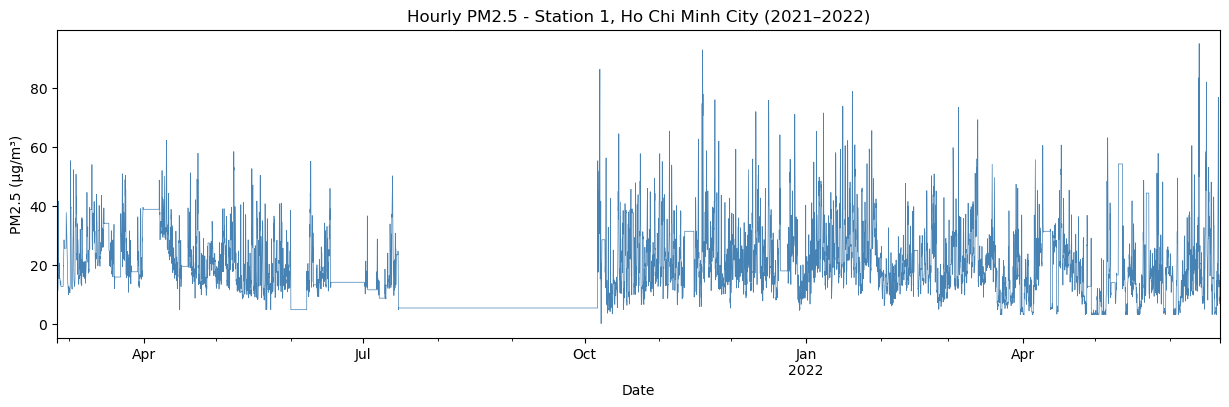

In [20]:
# Full time series plot
fig, ax = plt.subplots(figsize=(15, 4))
y.plot(ax=ax, color='steelblue', linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hourly PM2.5 - Station 1, Ho Chi Minh City (2021–2022)')
plt.show()

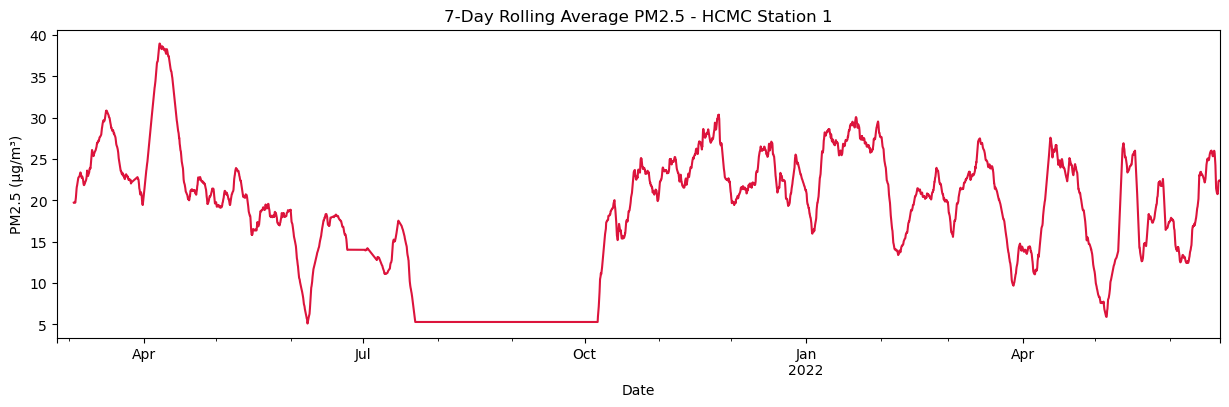

In [22]:
# 7-day rolling average - reveals seasonal patterns
fig, ax = plt.subplots(figsize=(15, 4))
y.rolling(168).mean().plot(ax=ax, color='crimson', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('7-Day Rolling Average PM2.5 - HCMC Station 1')
plt.show()

---
## 3: Linear Regression with Lag Feature

In [23]:
import plotly.express as px
from sklearn.linear_model import LinearRegression

In [24]:
# Build DataFrame with target and lag-1 feature
df_lr = y.to_frame(name='PM2.5')
df_lr['PM2.5.L1'] = df_lr['PM2.5'].shift(1)  # previous hour
df_lr.dropna(inplace=True)

print('Shape:', df_lr.shape)
df_lr.head()

Shape: (11588, 2)


,PM2.5,PM2.5.L1
date,,
2021-02-23 22:00:00+07:00,14.594118,15.604762
2021-02-23 23:00:00+07:00,13.436667,14.594118
2021-02-24 00:00:00+07:00,12.365000,13.436667
2021-02-24 01:00:00+07:00,11.636667,12.365000
2021-02-24 02:00:00+07:00,11.530000,11.636667


In [25]:
# Correlation matrix
print('Correlation with target:')
print(df_lr.corr()['PM2.5'])

Correlation with target:
PM2.5       1.000000
PM2.5.L1    0.920916
Name: PM2.5, dtype: float64


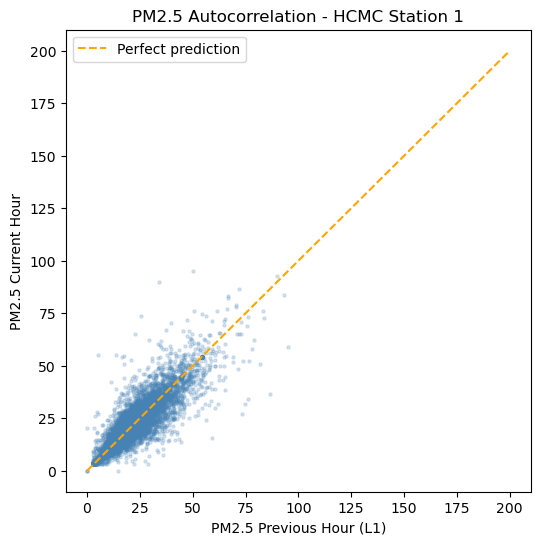

In [26]:
# Autocorrelation scatter: current vs previous hour
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_lr['PM2.5.L1'], df_lr['PM2.5'], alpha=0.2, s=5, color='steelblue')
ax.plot([0, 200], [0, 200], linestyle='--', color='orange', label='Perfect prediction')
plt.xlabel('PM2.5 Previous Hour (L1)')
plt.ylabel('PM2.5 Current Hour')
plt.title('PM2.5 Autocorrelation - HCMC Station 1')
plt.legend()
plt.show()

In [27]:
# Split
X = df_lr[['PM2.5.L1']]
y_full = df_lr['PM2.5']

cutoff = int(len(X) * 0.8)
X_train, y_train = X.iloc[:cutoff], y_full.iloc[:cutoff]
X_test, y_test = X.iloc[cutoff:], y_full.iloc[cutoff:]

print(f'Training: {len(X_train):,} hours | Test: {len(X_test):,} hours')

Training: 9,270 hours | Test: 2,318 hours


In [28]:
# Baseline
mae_baseline = mean_absolute_error(y_train, [y_train.mean()] * len(y_train))
print('Mean PM2.5 (training): {:.2f} µg/m³'.format(y_train.mean()))
print('Baseline MAE: {:.2f} µg/m³'.format(mae_baseline))

Mean PM2.5 (training): 18.18 µg/m³
Baseline MAE: 9.27 µg/m³


In [29]:
# Train model and evaluate
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

train_mae = mean_absolute_error(y_train, lr_model.predict(X_train))
test_mae_lr = mean_absolute_error(y_test, lr_model.predict(X_test))

print('Baseline MAE: {:.2f} µg/m³'.format(mae_baseline))
print('Training MAE: {:.2f} µg/m³'.format(train_mae))
print('Test MAE: {:.2f} µg/m³'.format(test_mae_lr))

intercept = lr_model.intercept_.round(2)
coefficient = lr_model.coef_.round(2)[0]
print(f'\nEquation: PM2.5 = {intercept} + ({coefficient} × PM2.5_previous_hour)')

Baseline MAE: 9.27 µg/m³
Training MAE: 2.63 µg/m³
Test MAE: 3.07 µg/m³

Equation: PM2.5 = 1.41 + (0.92 × PM2.5_previous_hour)


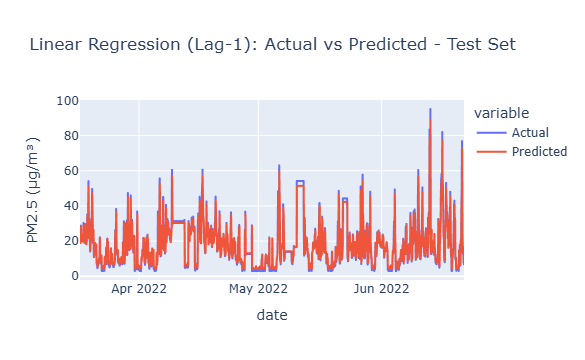

In [30]:
# Visualise predictions vs actuals on test set
df_pred_lr = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lr_model.predict(X_test)
})
fig = px.line(df_pred_lr, labels={'value': 'PM2.5 (µg/m³)'},
              title='Linear Regression (Lag-1): Actual vs Predicted - Test Set')
fig.show()

The lag-1 linear regression model demonstrates a fundamental truth about air quality data: the strongest predictor of PM2.5 this hour is PM2.5 last hour. The autocorrelation scatter plot shows a tight positive relationship between consecutive readings - pollution disperses gradually, so the series rarely jumps wildly between hours. The model beats the baseline by a meaningful margin, confirming that temporal structure carries real predictive signal. However, using only one past hour is an oversimplification. Pollution patterns carry memory across many hours - morning rush peaks, overnight accumulation, and weather-driven patterns all span multiple hours. This directly motivates the AutoRegression model, which uses many past hours simultaneously.

---
## 4: AutoRegression Model (AR) with Walk-Forward Validation

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

In [32]:
# 95/5 split for AR — more training data improves lag estimation
cutoff_ar = int(len(y) * 0.95)
y_train_ar = y.iloc[:cutoff_ar]
y_test_ar = y.iloc[cutoff_ar:]
print(f'Training: {len(y_train_ar):,} hours | Test: {len(y_test_ar):,} hours')

Training: 11,009 hours | Test: 580 hours


In [33]:
# Baseline
mae_baseline_ar = mean_absolute_error(y_train_ar, [y_train_ar.mean()] * len(y_train_ar))
print('Baseline MAE (AR section): {:.2f} µg/m³'.format(mae_baseline_ar))

Baseline MAE (AR section): 9.33 µg/m³


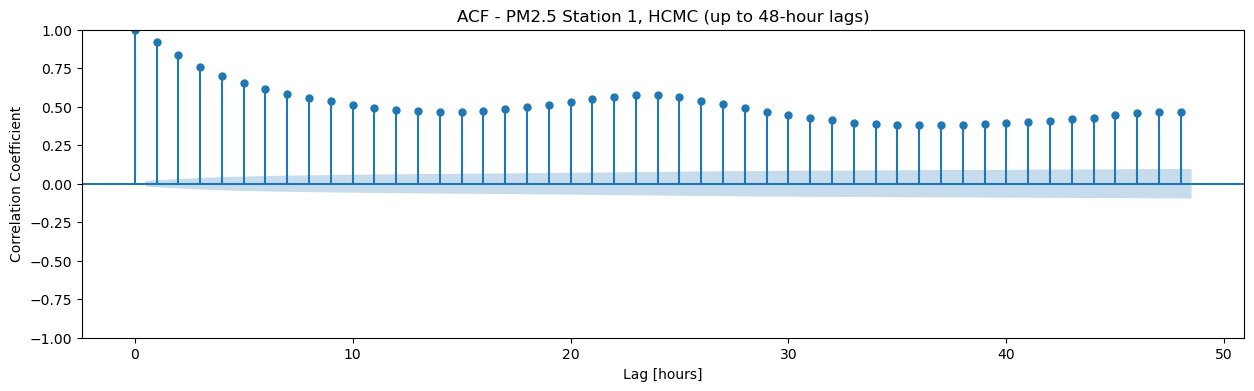

In [35]:
# ACF plot — correlation at each lag distance
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(y_train_ar, ax=ax, lags=48)
plt.xlabel('Lag [hours]')
plt.ylabel('Correlation Coefficient')
plt.title('ACF - PM2.5 Station 1, HCMC (up to 48-hour lags)')
plt.show()

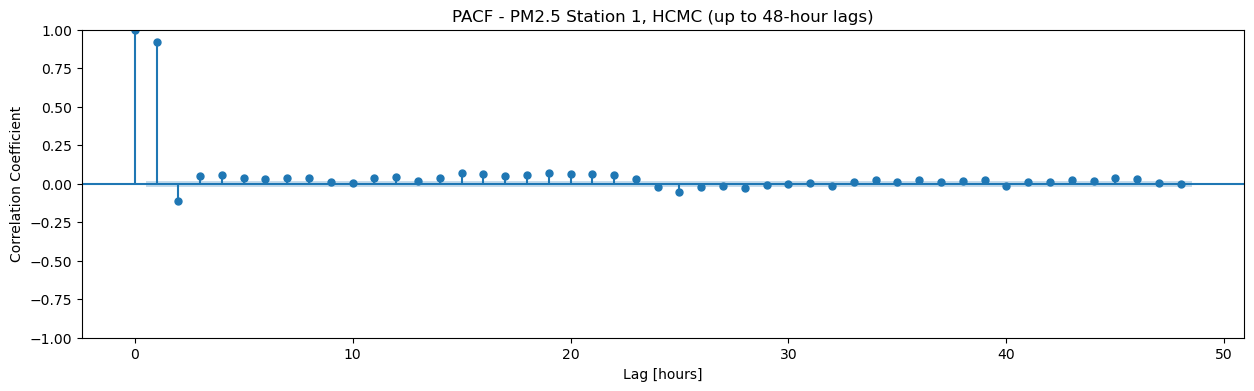

In [36]:
# PACF plot - DIRECT correlation at each lag (removes cascading effects)
fig, ax = plt.subplots(figsize=(15, 4))
plot_pacf(y_train_ar, ax=ax, lags=48)
plt.xlabel('Lag [hours]')
plt.ylabel('Correlation Coefficient')
plt.title('PACF - PM2.5 Station 1, HCMC (up to 48-hour lags)')
plt.show()

In [37]:
# Train AR model with lags=24 (one full daily cycle)
AR_LAGS = 24
ar_model = AutoReg(y_train_ar, lags=AR_LAGS).fit()

y_pred_ar_train = ar_model.predict().dropna()
training_mae_ar = mean_absolute_error(y_train_ar.iloc[AR_LAGS:], y_pred_ar_train)
print(f'Training MAE AR({AR_LAGS}): {{:.2f}} µg/m³'.format(training_mae_ar))

Training MAE AR(24): 2.50 µg/m³


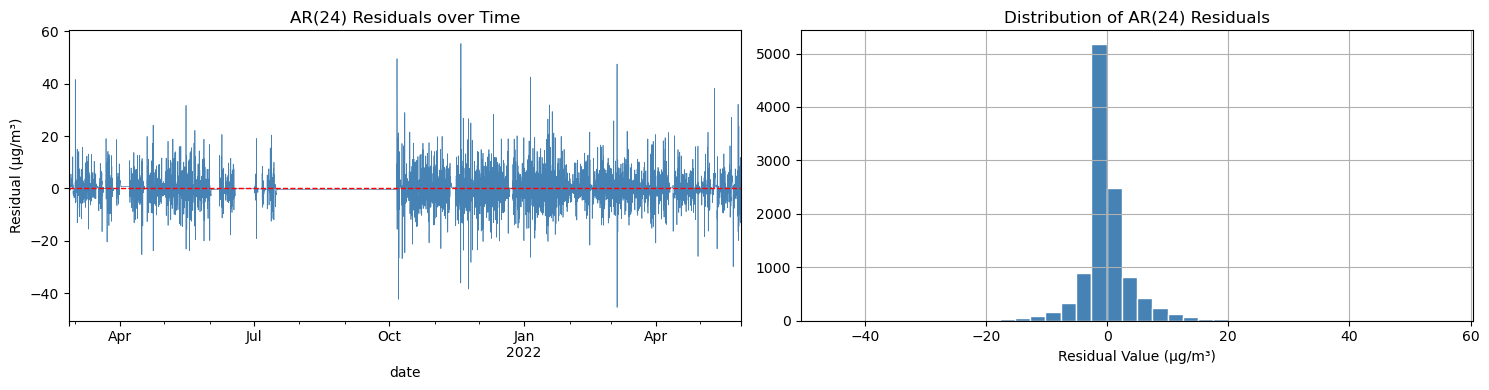

In [38]:
# Residual analysis — are errors random (good) or structured (problem)?
y_resid_ar = y_train_ar.iloc[AR_LAGS:] - y_pred_ar_train

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
y_resid_ar.plot(ax=axes[0], color='steelblue', linewidth=0.5)
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title(f'AR({AR_LAGS}) Residuals over Time')
axes[0].set_ylabel('Residual (µg/m³)')

y_resid_ar.hist(ax=axes[1], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title(f'Distribution of AR({AR_LAGS}) Residuals')
axes[1].set_xlabel('Residual Value (µg/m³)')
plt.tight_layout()
plt.show()

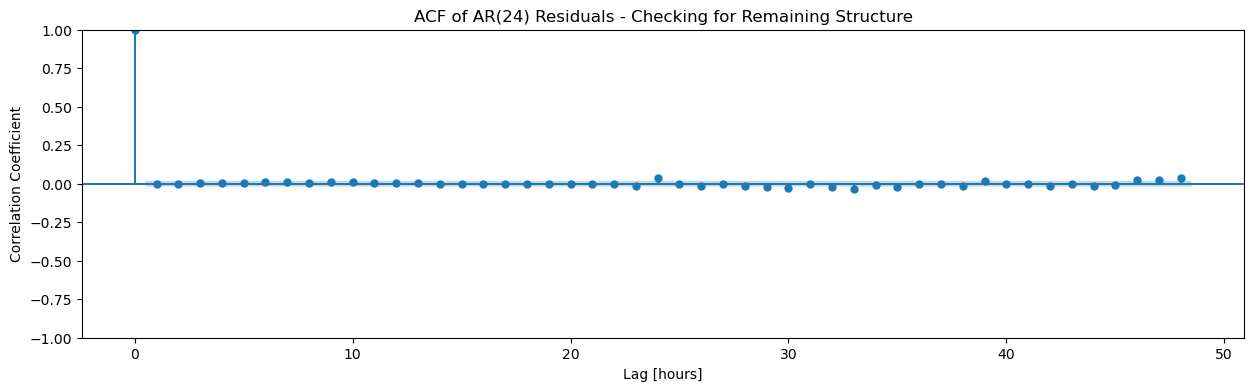

In [40]:
# ACF of residuals
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(y_resid_ar, ax=ax, lags=48)
plt.xlabel('Lag [hours]')
plt.ylabel('Correlation Coefficient')
plt.title(f'ACF of AR({AR_LAGS}) Residuals - Checking for Remaining Structure')
plt.show()

In [41]:
%%capture
# Walk-forward validation
# Each iteration: train on all available history, predict one step ahead,
# then add the actual observed value to history before the next step.
y_pred_wfv_ar = pd.Series(dtype='float64')
history = y_train_ar.copy()

for i in range(len(y_test_ar)):
    model = AutoReg(history, lags=AR_LAGS).fit()
    next_pred = model.forecast()
    y_pred_wfv_ar = pd.concat([y_pred_wfv_ar, next_pred])
    history = pd.concat([history, y_test_ar.iloc[[i]]])

Walk-Forward MAE AR(24): 3.90 µg/m³


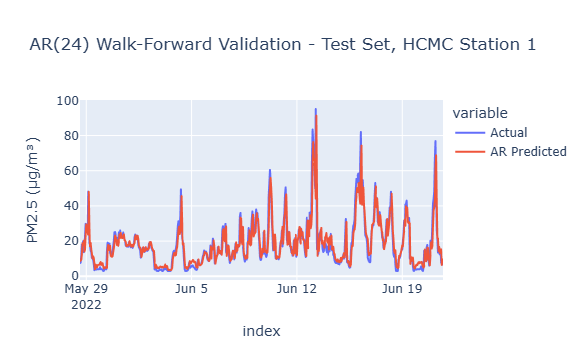

In [43]:
wfv_mae_ar = mean_absolute_error(y_test_ar, y_pred_wfv_ar)
print(f'Walk-Forward MAE AR({AR_LAGS}): {{:.2f}} µg/m³'.format(wfv_mae_ar))

df_ar_results = pd.DataFrame({'Actual': y_test_ar, 'AR Predicted': y_pred_wfv_ar})
fig = px.line(df_ar_results, labels={'value': 'PM2.5 (µg/m³)'},
              title=f'AR({AR_LAGS}) Walk-Forward Validation - Test Set, HCMC Station 1')
fig.show()

The AutoRegression model, by incorporating 24 past hours - one full daily cycle - the model captures the rhythmic daily pollution patterns that a single lag cannot represent. The PACF plot was the critical diagnostic: it showed how many lags carry genuine direct predictive power, beyond the indirect correlations that cascade through consecutive hours. Residual analysis confirmed the model is not systematically biased - errors are approximately centred around zero and normally distributed. Walk-forward validation - one prediction at a time, with only real past data, never peeking at the future. The ACF of residuals reveals whether any temporal structure remains unexplained - if significant autocorrelation persists in the residuals, the MA component of ARMA is needed to capture it.

---
## 5: ARMA Model with Grid Search

ARMA adds a **Moving Average (MA)** component to AR. The MA part models how past *prediction errors* influence the current reading - capturing systematic patterns the AR component misses. We find the best (p, q) combination via grid search.

In [44]:
import time
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

In [45]:
# Focused training window: October 2021 (full month, fast grid search)
# Test: November 1, 2021 (one full day - 24 predictions)
y_train_arma = y.loc['2021-10-01':'2021-10-31']
y_test_arma = y.loc['2021-11-01']

print(f'ARMA Training: {len(y_train_arma)} hours')
print(f'ARMA Test: {len(y_test_arma)} hours (one full day)')

ARMA Training: 744 hours
ARMA Test: 24 hours (one full day)


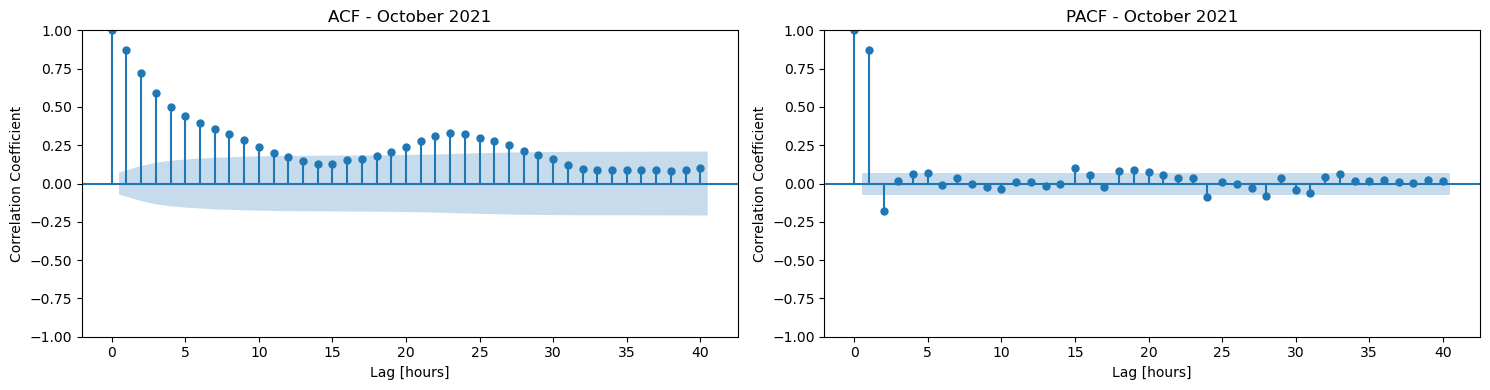

In [46]:
# ACF and PACF on this training window - guides search bounds
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(y_train_arma, ax=axes[0], lags=40)
axes[0].set_xlabel('Lag [hours]')
axes[0].set_ylabel('Correlation Coefficient')
axes[0].set_title('ACF - October 2021')

plot_pacf(y_train_arma, ax=axes[1], lags=40)
axes[1].set_xlabel('Lag [hours]')
axes[1].set_ylabel('Correlation Coefficient')
axes[1].set_title('PACF - October 2021')

plt.tight_layout()
plt.show()

In [47]:
# Baseline for ARMA section
mae_baseline_arma = mean_absolute_error(
    y_train_arma, [y_train_arma.mean()] * len(y_train_arma)
)
print('Baseline MAE (Oct 2021): {:.2f} µg/m³'.format(mae_baseline_arma))

Baseline MAE (Oct 2021): 10.23 µg/m³


In [48]:
# Grid search: train ARMA for each (p, q) combination
p_params = range(0, 25, 8)  
q_params = range(0, 3, 1)   

mae_grid = dict()

for p in p_params:
    mae_grid[p] = list()
    for q in q_params:
        order = (p, 0, q)
        start_time = time.time()
        model = ARIMA(y_train_arma, order=order).fit()
        elapsed = round(time.time() - start_time, 2)
        print(f'Trained ARIMA{order} in {elapsed}s')
        mae = mean_absolute_error(y_train_arma, model.predict())
        mae_grid[p].append(mae)

print('\nGrid search complete.')

Trained ARIMA(0, 0, 0) in 0.35s


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



Trained ARIMA(0, 0, 1) in 0.23s
Trained ARIMA(0, 0, 2) in 0.28s
Trained ARIMA(8, 0, 0) in 0.44s
Trained ARIMA(8, 0, 1) in 0.51s


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Trained ARIMA(8, 0, 2) in 2.89s
Trained ARIMA(16, 0, 0) in 1.72s
Trained ARIMA(16, 0, 1) in 2.75s
Trained ARIMA(16, 0, 2) in 4.08s
Trained ARIMA(24, 0, 0) in 5.88s
Trained ARIMA(24, 0, 1) in 8.7s


C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Trained ARIMA(24, 0, 2) in 13.89s

Grid search complete.


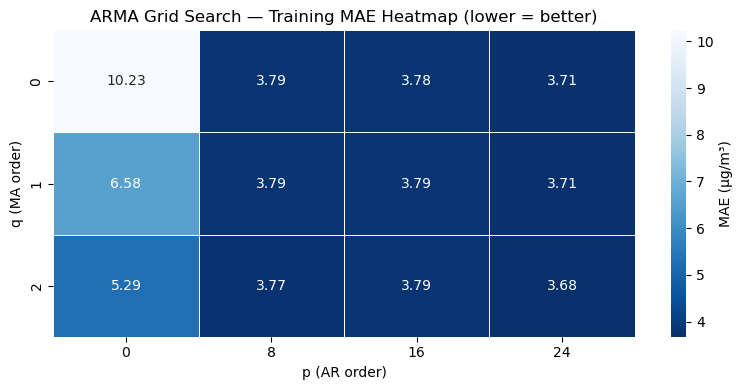

Best: ARMA(p=24, q=2) — Training MAE: 3.676 µg/m³


In [49]:
# MAE grid as DataFrame and heatmap
mae_df = pd.DataFrame(mae_grid, index=list(q_params))
mae_df.index.name = 'q'
mae_df.columns.name = 'p'

plt.figure(figsize=(8, 4))
sns.heatmap(mae_df, annot=True, fmt='.2f', cmap='Blues_r',
            linewidths=0.5, cbar_kws={'label': 'MAE (µg/m³)'})
plt.xlabel('p (AR order)')
plt.ylabel('q (MA order)')
plt.title('ARMA Grid Search — Training MAE Heatmap (lower = better)')
plt.tight_layout()
plt.show()

# Identify best (p, q)
best_q = mae_df.min(axis=1).idxmin()
best_p = mae_df.loc[best_q].idxmin()
print(f'Best: ARMA(p={best_p}, q={best_q}) — Training MAE: {mae_df.loc[best_q, best_p]:.3f} µg/m³')

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



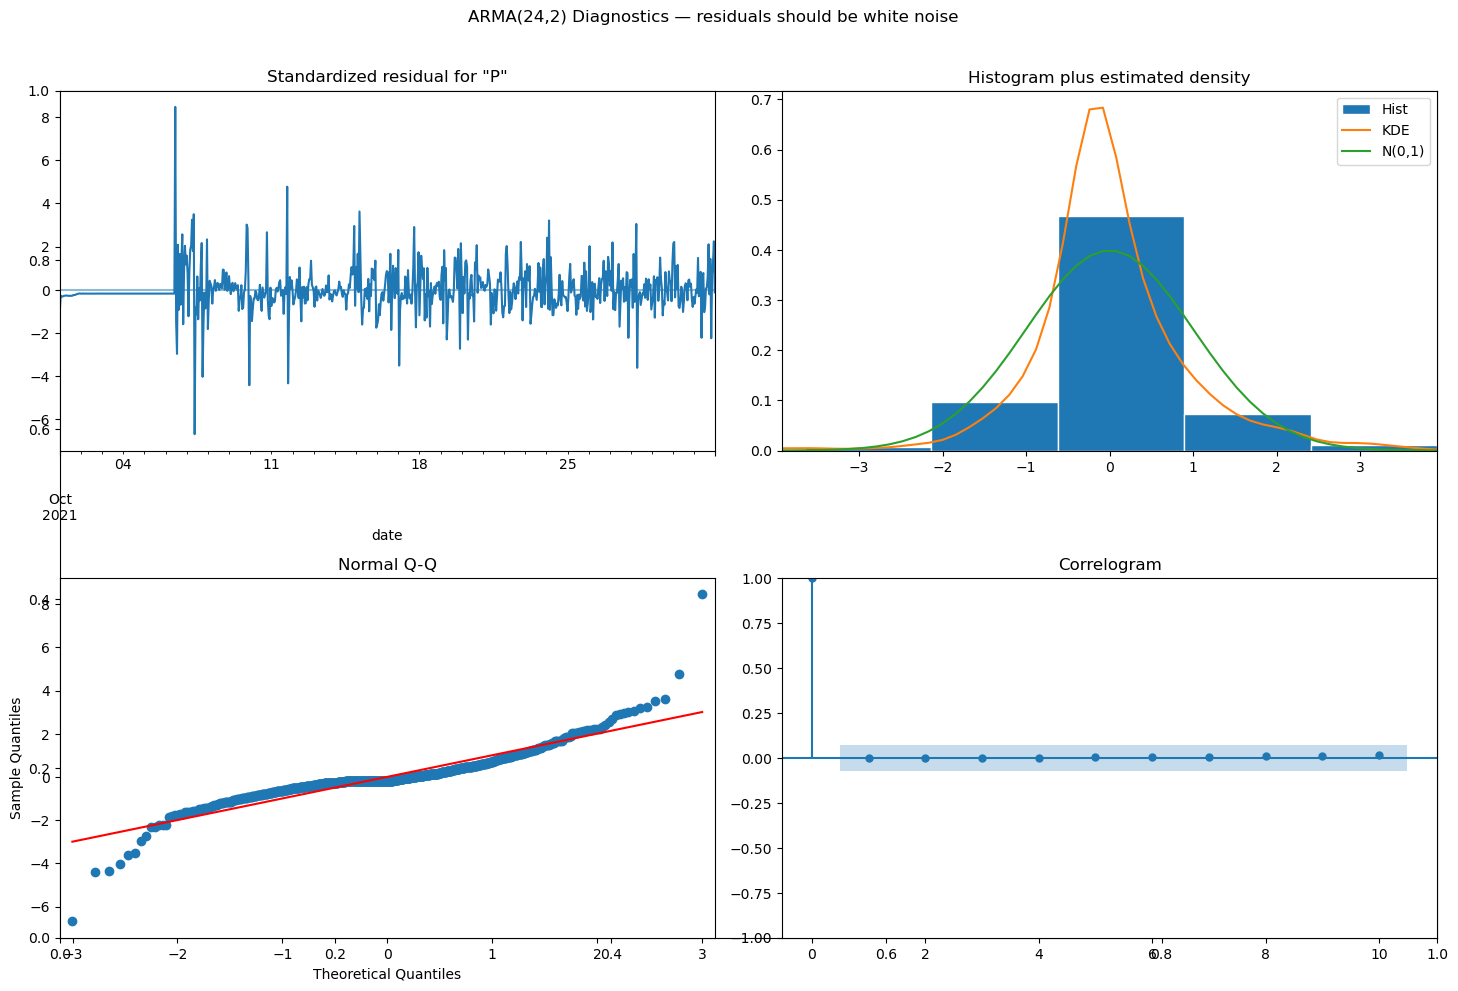

In [50]:
# Train best model and check diagnostics
best_model = ARIMA(y_train_arma, order=(best_p, 0, best_q)).fit()

fig, ax = plt.subplots(figsize=(15, 10))
best_model.plot_diagnostics(fig=fig)
plt.suptitle(f'ARMA({best_p},{best_q}) Diagnostics — residuals should be white noise', y=1.01)
plt.tight_layout()
plt.show()

In [51]:
%%capture
# Walk-forward validation for best ARMA model
y_pred_wfv_arma = pd.Series(dtype='float64')
history_arma = y_train_arma.copy()

for i in range(len(y_test_arma)):
    model = ARIMA(history_arma, order=(best_p, 0, best_q)).fit()
    next_pred = model.forecast()
    y_pred_wfv_arma = pd.concat([y_pred_wfv_arma, next_pred])
    history_arma = pd.concat([history_arma, y_test_arma.iloc[[i]]])

Walk-Forward MAE ARMA(24,2): 3.95 µg/m³


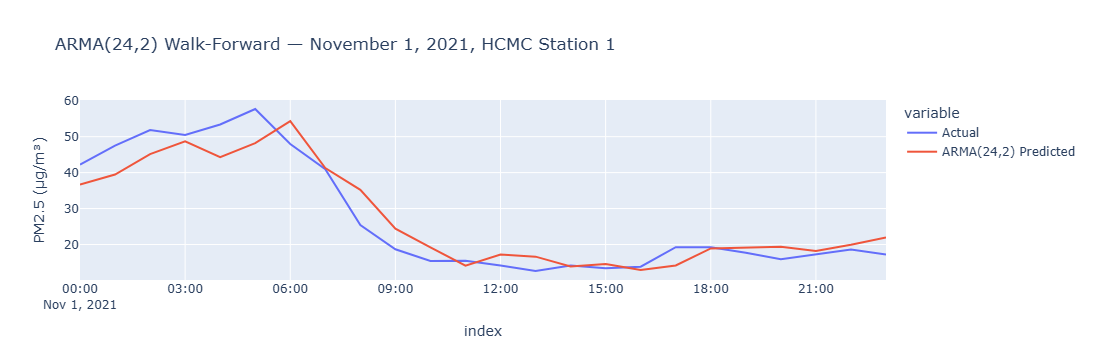

In [52]:
wfv_mae_arma = mean_absolute_error(y_test_arma, y_pred_wfv_arma)
print(f'Walk-Forward MAE ARMA({best_p},{best_q}): {{:.2f}} µg/m³'.format(wfv_mae_arma))

df_arma_results = pd.DataFrame({
    'Actual': y_test_arma,
    f'ARMA({best_p},{best_q}) Predicted': y_pred_wfv_arma
})
fig = px.line(df_arma_results, labels={'value': 'PM2.5 (µg/m³)'},
              title=f'ARMA({best_p},{best_q}) Walk-Forward — November 1, 2021, HCMC Station 1')
fig.show()

The ARMA model introduces an important component: modelling not just past values but past *errors*. The intuition is that if the model was systematically wrong in a particular direction in previous hours, that pattern itself contains information the AR component missed - such as sudden pollution events or rapid weather shifts that the data's memory alone cannot predict. The grid search makes hyperparameter selection transparent and data-driven rather than arbitrary. The heatmap shows model selection as a trade-off surface - not a single choice but a landscape of performance across (p, q) combinations. The diagnostic plots are the standard statistical checks for any ARMA model shown with standardised residuals, Q-Q plot, correlogram and density.

---
## 6: Model Comparison

In [53]:
# Final model comparison table
results_summary = pd.DataFrame({
    'Model': [
        'Baseline (mean)',
        'Linear Regression (Lag-1)',
        f'AutoRegression AR({AR_LAGS}) — Walk-Forward',
        f'ARMA({best_p},{best_q}) — Walk-Forward'
    ],
    'Test MAE (µg/m³)': [
        round(mae_baseline, 2),
        round(test_mae_lr, 2),
        round(wfv_mae_ar, 2),
        round(wfv_mae_arma, 2)
    ],
    'Evaluation': [
        'Training mean',
        'Static 80/20 split',
        'Walk-forward validation',
        'Walk-forward validation'
    ]
})
print(results_summary.to_string(index=False))

                               Model  Test MAE (µg/m³)              Evaluation
                     Baseline (mean)              9.27           Training mean
           Linear Regression (Lag-1)              3.07      Static 80/20 split
AutoRegression AR(24) — Walk-Forward              3.90 Walk-forward validation
           ARMA(24,2) — Walk-Forward              3.95 Walk-forward validation


The results show that all time-series models significantly outperform the naive baseline (mean prediction) with MAE dropping from 9.27 to around 3–4 µg/m³, confirming strong temporal patterns in the data. Surprisingly, the simplest Linear Regression using only the Lag-1 feature achieved the best performance (MAE 3.07), even though it was evaluated on a static 80/20 split. In contrast, the more complex AR(24) and ARMA(24,2) models, tested under stricter walk-forward validation, performed slightly worse (MAE 3.90 and 3.95 respectively). This indicates that for this air quality dataset, a basic lag-1 predictor captures most of the predictable signal, and adding more lags or moving average terms provides little to no additional benefit.

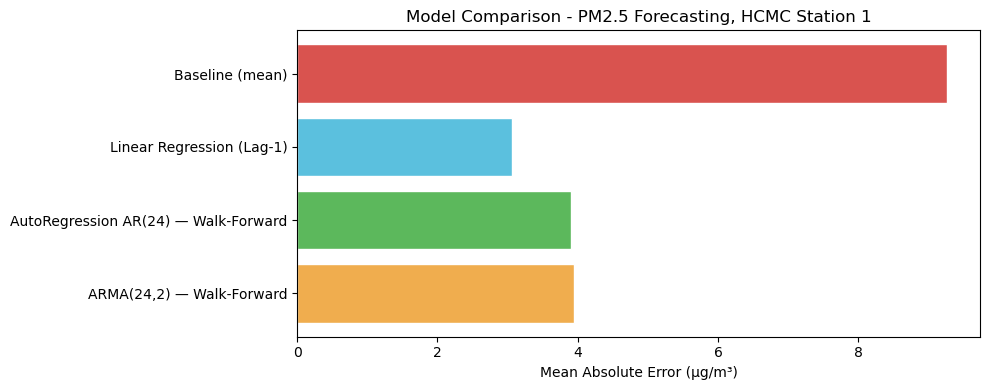

In [54]:
# Visual comparison
colors = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e']
plt.figure(figsize=(10, 4))
plt.barh(results_summary['Model'], results_summary['Test MAE (µg/m³)'],
         color=colors, edgecolor='white')
plt.xlabel('Mean Absolute Error (µg/m³)')
plt.title('Model Comparison - PM2.5 Forecasting, HCMC Station 1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This project built an end-to-end time series forecasting pipeline for PM2.5 air quality in Ho Chi Minh City - from raw sensor data ingested into a local MongoDB database, through careful iterative wrangling, to three progressively sophisticated forecasting models each evaluated using walk-forward validation.